In [10]:
import nibabel as nib
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Mask')

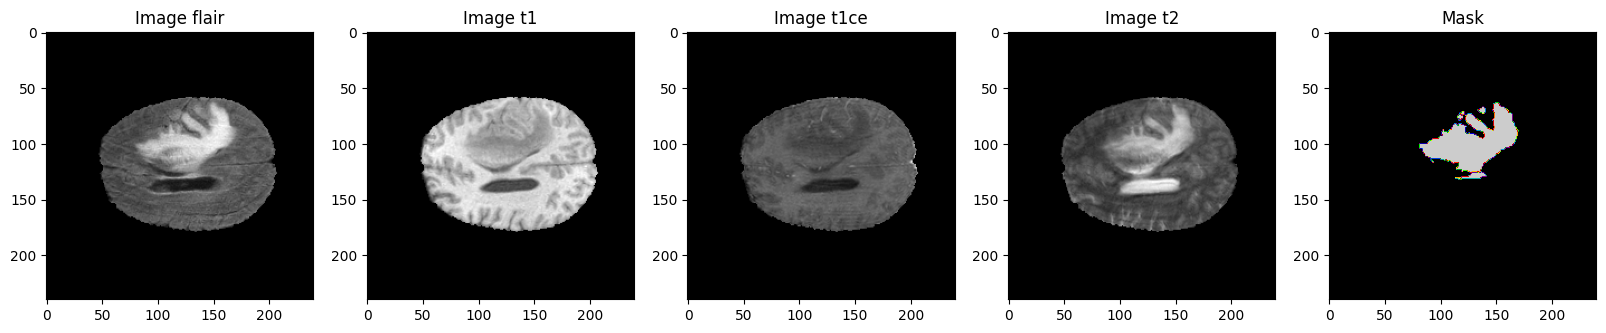

In [11]:
TRAIN_DATASET_PATH = '../input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/'

test_image_flair=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_flair.nii').get_fdata()
test_image_t1=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t1.nii').get_fdata()
test_image_t1ce=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t1ce.nii').get_fdata()
test_image_t2=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_t2.nii').get_fdata()
test_mask=nib.load(TRAIN_DATASET_PATH + 'BraTS20_Training_001/BraTS20_Training_001_seg.nii').get_fdata()


fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1,5, figsize = (20, 10))
slice_w = 25
ax1.imshow(test_image_flair[:,:,test_image_flair.shape[0]//2-slice_w], cmap = 'gray')
ax1.set_title('Image flair')
ax2.imshow(test_image_t1[:,:,test_image_t1.shape[0]//2-slice_w], cmap = 'gray')
ax2.set_title('Image t1')
ax3.imshow(test_image_t1ce[:,:,test_image_t1ce.shape[0]//2-slice_w], cmap = 'gray')
ax3.set_title('Image t1ce')
ax4.imshow(test_image_t2[:,:,test_image_t2.shape[0]//2-slice_w], cmap = 'gray')
ax4.set_title('Image t2')

# ax5.imshow(test_mask[:,:,test_mask.shape[0]//2-slice_w])
ax5.imshow(test_mask[:,:,test_mask.shape[0]//2-slice_w], cmap='nipy_spectral')

ax5.set_title('Mask')

In [12]:
import cv2
import numpy as np

In [13]:
# pick slice with maximum tumor area
mask_area_per_slice = test_mask.sum(axis=(0, 1))
if np.any(mask_area_per_slice > 0):
    slice_idx = int(np.argmax(mask_area_per_slice))
else:
    slice_idx = int(test_image_t2.shape[2] // 2)

# extract slice and binarize mask (>0)
img = test_image_t2[:, :, slice_idx].astype(np.float32)
mask_slice = (test_mask[:, :, slice_idx] > 0).astype(np.uint8) * 255

# mormalize image to 0-255 uint8 for OpenCV
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
height, width = img.shape
print(f"Sample slice {slice_idx} loaded: shape {img.shape}, tumor pixels: {int(mask_slice.sum()//255)}")

Sample slice 68 loaded: shape (240, 240), tumor pixels: 5040


### Anisotropic Diffusio Filter

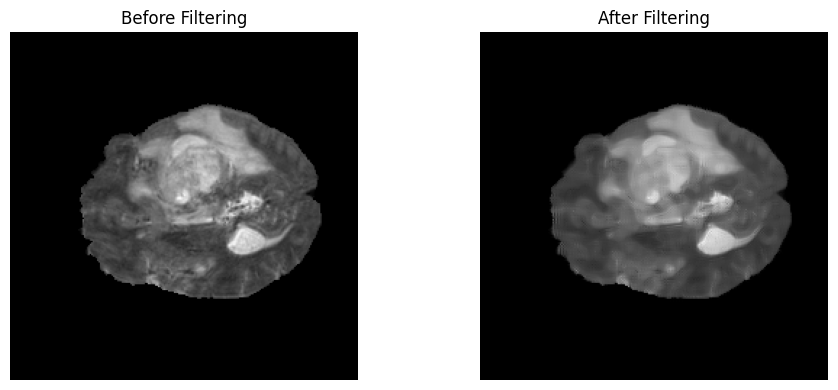

In [14]:
# anisotropic diffusion filter

def _grad_xy(u):
    gx = np.zeros_like(u, dtype=np.float32)
    gy = np.zeros_like(u, dtype=np.float32)
    gx[:, 1:-1] = 0.5 * (u[:, 2:] - u[:, :-2])
    gx[:, 0] = u[:, 1] - u[:, 0]
    gx[:, -1] = u[:, -1] - u[:, -2]
    gy[1:-1, :] = 0.5 * (u[2:, :] - u[:-2, :])
    gy[0, :] = u[1, :] - u[0, :]
    gy[-1, :] = u[-1, :] - u[-2, :]
    return gx, gy


def _div(nx, ny):
    dx = np.zeros_like(nx, dtype=np.float32)
    dy = np.zeros_like(ny, dtype=np.float32)
    dx[:, 1:-1] = nx[:, 1:-1] - nx[:, 0:-2]
    dx[:, 0] = 0.0
    dx[:, -1] = nx[:, -1] - nx[:, -2]
    dy[1:-1, :] = ny[1:-1, :] - ny[0:-2, :]
    dy[0, :] = 0.0
    dy[-1, :] = ny[-1, :] - ny[-2, :]
    return dx + dy


def anisotropic_diffusion(
    img,
    num_iter=15,
    k=25.0,
    gamma=0.1,

    # exp for g(s)
    option='exp',

    # 'alvarez' for selective smoothing
    model='alvarez',

    # Gaussian pre-smoothing for g(|∇(Gσ*u)|)
    sigma=1.0
):
    """
    Implements anisotropic diffusion:
    - model='alvarez': ∂u/∂t = g(|∇(Gσ*u)|) * |∇u| * div(∇u/|∇u|)
      (Selective smoothing via mean-curvature motion with edge-stopping g)
    - model='pm': Perona–Malik with exponential/reciprocal conduction.
    Zero-flux (Neumann) boundary conditions.
    """
    u = img.astype(np.float32)
    gamma = float(min(gamma, 0.25))
    eps = 1e-6

    def g_func(s):
        if option == 'recip':
            return 1.0 / (1.0 + (s / k) ** 2)
        return np.exp(- (s / k) ** 2)

    for _ in range(num_iter):
        if model == 'alvarez':
            
            # pre-smooth for robust edge detection in g(|∇(Gσ*u)|)
            u_blur = cv2.GaussianBlur(u, ksize=(0, 0), sigmaX=sigma, sigmaY=sigma)
            gx_b, gy_b = _grad_xy(u_blur)
            mag_b = np.sqrt(gx_b * gx_b + gy_b * gy_b) + eps
            g = g_func(mag_b)

            # geometric terms on the current image u
            gx, gy = _grad_xy(u)
            mag = np.sqrt(gx * gx + gy * gy) + eps
            nx = gx / mag
            ny = gy / mag
            curvature = _div(nx, ny)

            u += gamma * (g * mag * curvature)
        else:  # perona–Malik (classic)
            # 4-neighborhood differences (neighbor - center)
            dN = np.zeros_like(u); dN[1:, :] = u[:-1, :] - u[1:, :]
            dS = np.zeros_like(u); dS[:-1, :] = u[1:, :] - u[:-1, :]
            dE = np.zeros_like(u); dE[:, :-1] = u[:, 1:] - u[:, :-1]
            dW = np.zeros_like(u); dW[:, 1:] = u[:, :-1] - u[:, 1:]

            def c_fn(g):
                if option == 'recip':
                    return 1.0 / (1.0 + (g / k) ** 2)
                return np.exp(- (g / k) ** 2)

            cN = c_fn(np.abs(dN))
            cS = c_fn(np.abs(dS))
            cE = c_fn(np.abs(dE))
            cW = c_fn(np.abs(dW))
            u += gamma * (cN * dN + cS * dS + cE * dE + cW * dW)

    return np.clip(u, 0, 255).astype(np.uint8)

# apply the filter to sample image
img_before = img.copy()
img = anisotropic_diffusion(img, num_iter=20, k=25, gamma=0.1, option='exp', model='alvarez', sigma=1.0)
img_after = img

# plot results
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_before.astype(np.uint8), cv2.COLOR_GRAY2RGB))
plt.title('Before Filtering')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_after.astype(np.uint8), cv2.COLOR_GRAY2RGB))
plt.title('After Filtering')
plt.axis('off')
plt.tight_layout()
plt.show()

### Step 2: Threshold to find bright seed points

In [15]:
ret, th = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
indexes = [(j, i) for j in range(height) for i in range(width) if th[j, i] == 255]

# choose the brightest pixel as seed for better tumor detection
seed_intensities = [img[j, i] for (j, i) in indexes]

# pixel with max intensity
seed = indexes[np.argmax(seed_intensities)]
print('Seed point:', seed)

Seed point: (144, 154)


### Step 3: Region Growing Function
- Initialize a seed point
- Neighbour pixels with similar characteristics which satisfy the growth criteria would be merged
- This searching and merging process will be iterated until there are no pixels to merge


In [16]:
def region_growing(img, seed, region_threshold=41):
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    height, width = img.shape
    segmented_img = np.zeros((height, width), np.uint8)

    # start region with seed
    region_mean = float(img[seed])
    region_size = 1
    neighbor_points_list = [seed]

    while neighbor_points_list:
        current_pixel = neighbor_points_list.pop(0)
        x, y = current_pixel
        segmented_img[x, y] = 255

        for dx, dy in neighbors:
            xn, yn = x + dx, y + dy
            if 0 <= xn < height and 0 <= yn < width and segmented_img[xn, yn] == 0:
                intensity_diff = abs(int(img[xn, yn]) - region_mean)
                if intensity_diff <= region_threshold:
                    segmented_img[xn, yn] = 255
                    neighbor_points_list.append((xn, yn))

                    # update region mean
                    region_mean = (region_mean * region_size + int(img[xn, yn])) / (region_size + 1)
                    region_size += 1

    return segmented_img

### Step 4: Segment and Highlight Tumor

In [17]:
# threhold value: 41
segmented_img = region_growing(img, seed, region_threshold=41)

highlighted = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
highlighted[segmented_img == 255] = [0, 0, 255]

### Step 6: Display Results

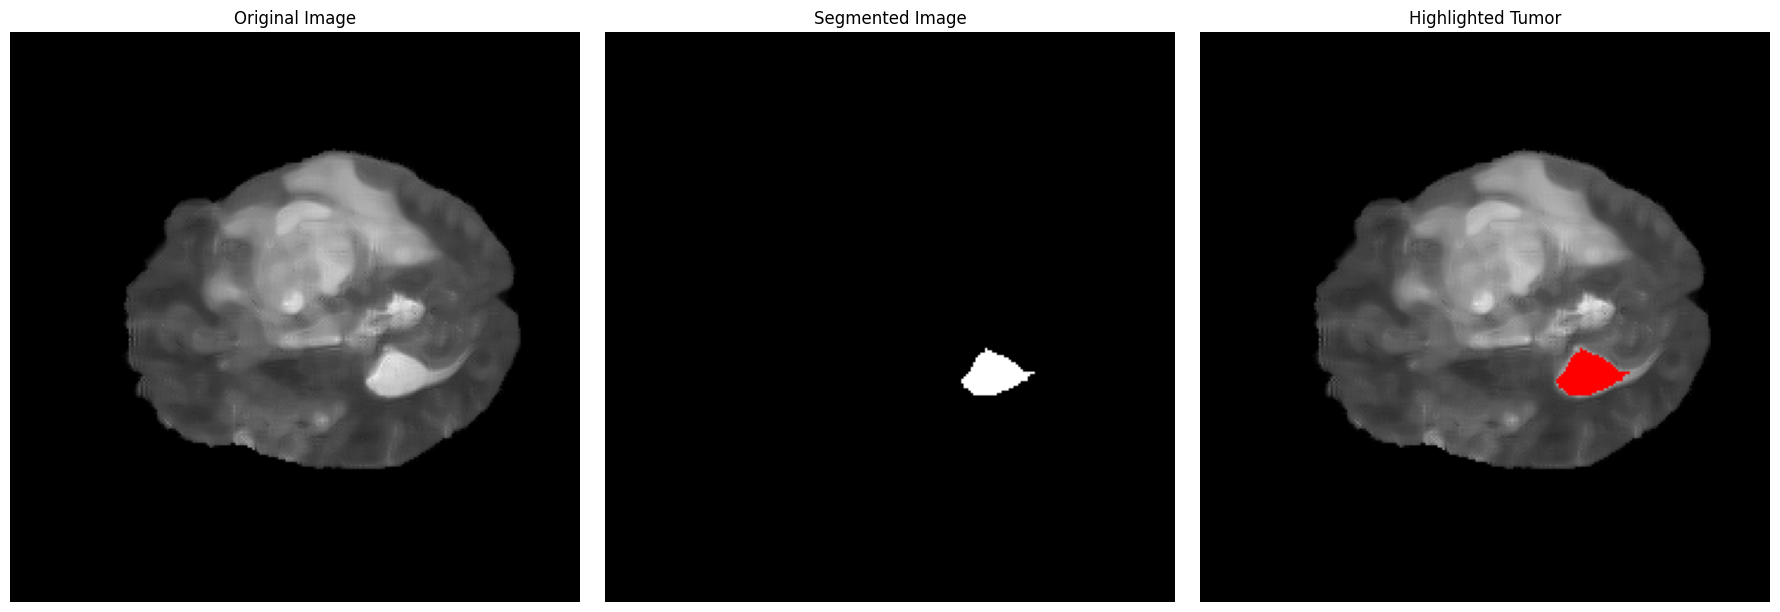

In [18]:
# plot results

img_display = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
segmented_display = cv2.cvtColor(segmented_img, cv2.COLOR_GRAY2RGB)
highlighted_display = cv2.cvtColor(highlighted, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(18, 6))

# original image
plt.subplot(1, 3, 1)
plt.imshow(img_display)
plt.title('Original Image')
plt.axis('off')

# segmented image
plt.subplot(1, 3, 2)
plt.imshow(segmented_display)
plt.title('Segmented Image')
plt.axis('off')

# highlighted image
plt.subplot(1, 3, 3)
plt.imshow(highlighted_display)
plt.title('Highlighted Tumor')
plt.axis('off')

plt.tight_layout()
plt.show()

### Step 7: Apply the Filter to the Traning Dataset

In [19]:
import glob
import os
from tqdm.auto import tqdm

In [20]:
# configs
ALL_CASES_PATH = TRAIN_DATASET_PATH.rstrip("/") + "/"
use_modality = "t2"

# apply anisotropic filter to all the training images
def apply_anisotropic_filter_to_all(all_cases_path, modality="t2", num_iter=20, k=25, gamma=0.1, sigma=1.0):
    case_dirs = sorted([d for d in glob.glob(os.path.join(all_cases_path, "BraTS20_Training_*")) 
                        if os.path.isdir(d)])
    if not case_dirs:
        raise FileNotFoundError(f"No case folders found in: {all_cases_path}")

    # store intensity distributions
    filtered = []
    stats_list = []
    pbar = tqdm(case_dirs, desc="Filtering", unit="case")

    for case_dir in pbar:
        case_id = os.path.basename(case_dir)
        mod_glob = glob.glob(os.path.join(case_dir, f"{case_id}_{modality}.nii*"))
        seg_glob = glob.glob(os.path.join(case_dir, f"{case_id}_seg.nii*"))
        if not mod_glob or not seg_glob:
            continue
        mod_path = mod_glob[0]
        seg_path = seg_glob[0]

        vol = nib.load(mod_path).get_fdata().astype(np.float32)
        seg = nib.load(seg_path).get_fdata().astype(np.float32)

        areas = seg.sum(axis=(0, 1))

        # keep the slice with maximum tumor area of each case
        if np.any(areas > 0):
            k_slice = int(np.argmax(areas))
        else:
            k_slice = vol.shape[2] // 2

        img_slice_f = vol[:, :, k_slice]
        mask_slice = (seg[:, :, k_slice] > 0).astype(np.uint8) * 255

        img_u8 = cv2.normalize(img_slice_f, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # apply filter
        img_filt = anisotropic_diffusion(
            img_u8,
            num_iter=num_iter,
            k=k,
            gamma=gamma,
            option='exp',
            model='alvarez',
            sigma=sigma
        )

        # store stats
        stats_list.append({
            "case": case_id,
            "slice": k_slice,
            "mean": float(img_filt.mean()),
            "std": float(img_filt.std())
        })

        filtered.append({
            "case": case_id,
            "slice": k_slice,
            "mod": modality,
            "img_orig": img_u8,
            "img_filt": img_filt,
            "mask_slice": mask_slice
        })

    print('\nSuccessfully applied anisotropic diffusion filter to all traning images')
    return filtered, stats_list

filtered_cases, stats_list = apply_anisotropic_filter_to_all(
    ALL_CASES_PATH, use_modality, num_iter=20, k=25, gamma=0.1, sigma=1.0)

Filtering:   0%|          | 0/369 [00:00<?, ?case/s]


Successfully applied anisotropic diffusion filter to all traning images


### Step 8: Display Intensity Distributions After Filtering

In [21]:
import pandas as pd

Training slice count: 368


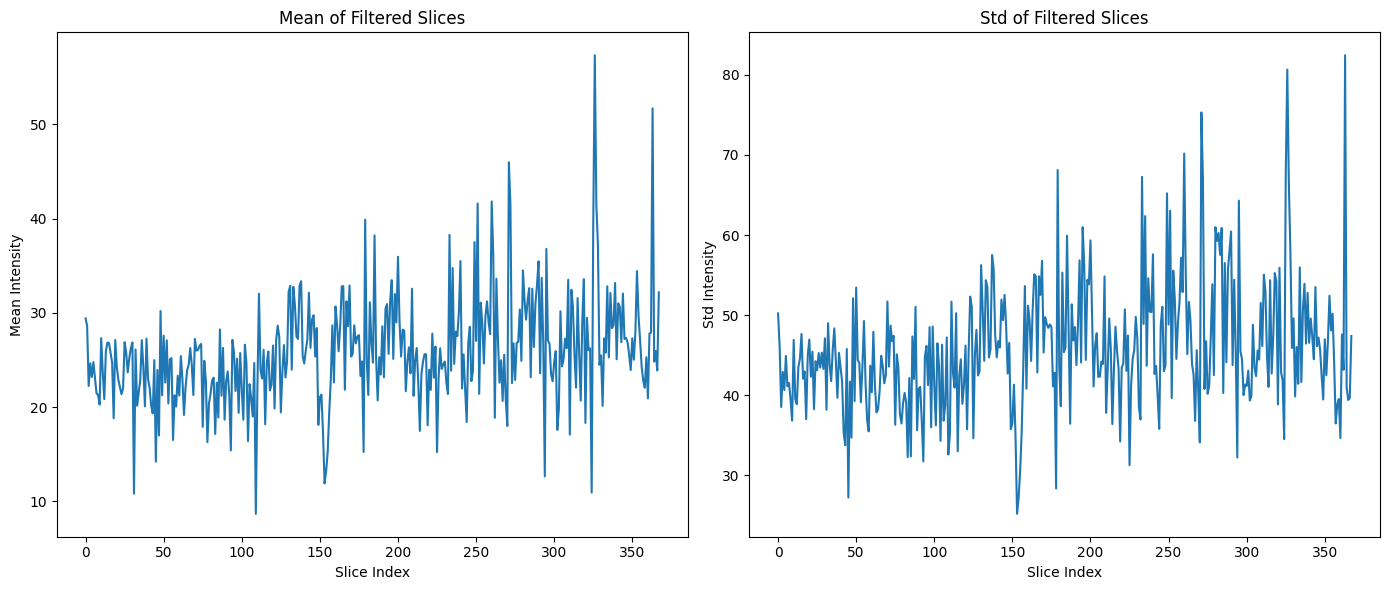

In [22]:
df = pd.DataFrame(stats_list)

print('Training slice count:', df.shape[0])

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(df["mean"])
plt.title("Mean of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Mean Intensity")

plt.subplot(1,2,2)
plt.plot(df["std"])
plt.title("Std of Filtered Slices")
plt.xlabel("Slice Index")
plt.ylabel("Std Intensity")

plt.tight_layout()
plt.show()

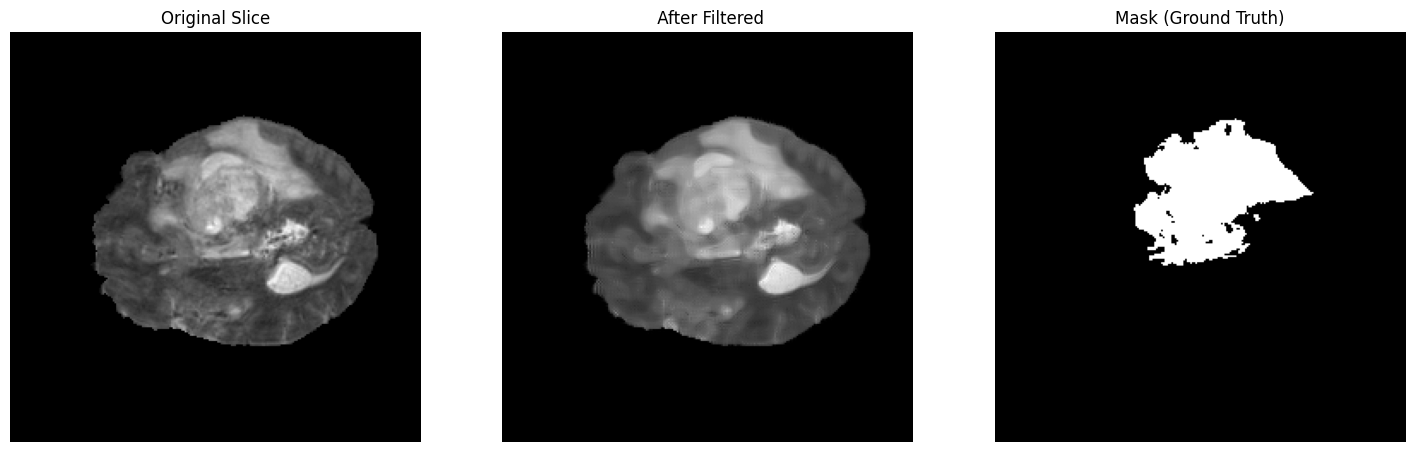

In [23]:
# take the first filtered case
first_case = filtered_cases[0]

img_orig = first_case["img_orig"]
img_filt = first_case["img_filt"]
mask = first_case["mask_slice"]

plt.figure(figsize=(18, 6))

# original slice
plt.subplot(1, 3, 1)
plt.imshow(img_orig, cmap='gray')
plt.title("Original Slice")
plt.axis('off')

# filtered slcie
plt.subplot(1, 3, 2)
plt.imshow(img_filt, cmap='gray')
plt.title(" After Filtered")
plt.axis('off')

# mask
plt.subplot(1, 3, 3)
plt.imshow(mask, cmap='gray')
plt.title("Mask (Ground Truth)")
plt.axis('off')

plt.show()

## Region Growing Segmentation: Evaluation Pipeline

### Metrics functions – Dice Similarity Coefficient (DSC) and Normalized Surface Dice (NSD)

In [24]:
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt

def dice_coefficient(y_true, y_pred, eps=1e-7):
    """
    y_true, y_pred: binary masks (0/1 or False/True)
    """
    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)
    
    intersection = np.logical_and(y_true, y_pred).sum()
    return (2.0 * intersection + eps) / (y_true.sum() + y_pred.sum() + eps)


def normalized_surface_dice(pred, gt, tolerance=2):
    """
    Normalized Surface Dice (NSD) for 2D masks.

    pred, gt: binary masks (0/1 or False/True)
    tolerance: distance threshold in pixels (≈ mm if spacing=1mm)
    """
    pred = np.asarray(pred).astype(bool)
    gt   = np.asarray(gt).astype(bool)

    # handle empty cases
    if pred.sum() == 0 and gt.sum() == 0:
        return 1.0
    if pred.sum() == 0 or gt.sum() == 0:
        return 0.0

    struct = np.ones((3, 3), dtype=bool)

    # extract 1-pixel wide boundary (surface) of each mask
    pred_surface = np.logical_xor(
        pred, binary_erosion(pred, structure=struct, border_value=0)
    )
    gt_surface = np.logical_xor(
        gt, binary_erosion(gt, structure=struct, border_value=0)
    )

    if pred_surface.sum() == 0 or gt_surface.sum() == 0:
        return 0.0

    
    dist_map = distance_transform_edt(~gt_surface)

    
    distances = dist_map[pred_surface]

    if distances.size == 0:
        return 0.0

    
    nsd = np.mean(distances <= tolerance)
    return float(nsd)


### Helper: get a seed point for each slice
Automatically choose a seed from the brightest region after Otsu thresholding

In [25]:
def choose_seed_from_image(img):
    """
    img: uint8 2D slice (0-255)
    returns seed as (row, col)
    """
    h, w = img.shape
    
    
    _, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    ys, xs = np.where(th == 255)
    if len(ys) == 0:
        
        return (h // 2, w // 2)
    
    
    intensities = img[ys, xs]
    idx_max = np.argmax(intensities)
    return int(ys[idx_max]), int(xs[idx_max])


### Run region growing + compute DSC & NSD for all filtered slices

In [26]:
import pandas as pd

results = []

for case in filtered_cases:
    img_filt = case["img_filt"].astype(np.uint8)
    gt_mask  = (case["mask_slice"] > 0).astype(np.uint8)   # 0/1 mask

    
    if gt_mask.sum() == 0:
        continue

    
    seed = choose_seed_from_image(img_filt)

    
    segmented = region_growing(img_filt, seed, region_threshold=41)

    
    pred_mask = (segmented > 0).astype(np.uint8)

    # evaluation metrics
    dsc = dice_coefficient(gt_mask, pred_mask)
    nsd = normalized_surface_dice(pred_mask, gt_mask, tolerance=2)

    results.append({
        "case": case["case"],
        "slice": case["slice"],
        "dice": dsc,
        "nsd": nsd
    })

results_df = pd.DataFrame(results)
results_df.head(), results_df.describe()


(                   case  slice          dice  nsd
 0  BraTS20_Training_001     68  1.855288e-11  0.0
 1  BraTS20_Training_002     53  4.748338e-11  0.0
 2  BraTS20_Training_003     72  1.312336e-10  0.0
 3  BraTS20_Training_004     84  3.370408e-11  0.0
 4  BraTS20_Training_005     95  1.278772e-10  0.0,
             slice          dice         nsd
 count  368.000000  3.680000e+02  368.000000
 mean    78.108696  1.374032e-01    0.066105
 std     17.469604  2.715165e-01    0.140272
 min     22.000000  1.495215e-11    0.000000
 25%     64.000000  3.604580e-11    0.000000
 50%     79.000000  5.566400e-11    0.000000
 75%     91.000000  8.892102e-02    0.044480
 max    128.000000  9.261618e-01    0.723971)

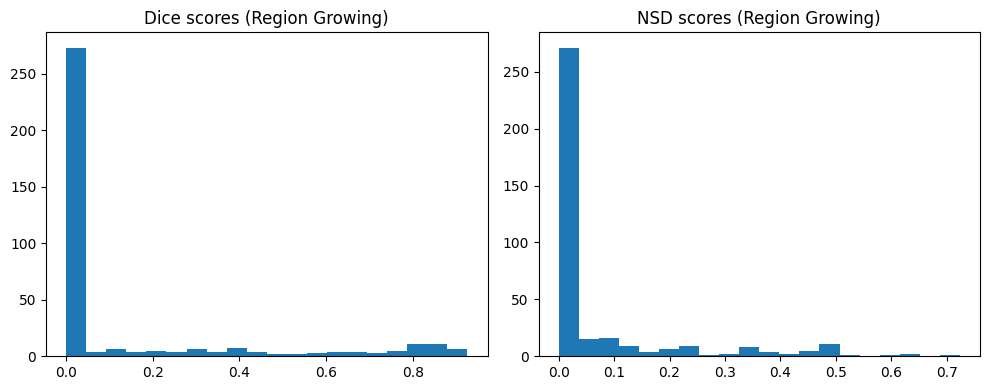

In [27]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(results_df["dice"], bins=20)
plt.title("Dice scores (Region Growing)")
plt.subplot(1,2,2)
plt.hist(results_df["nsd"], bins=20)
plt.title("NSD scores (Region Growing)")
plt.tight_layout()
plt.show()

### Comparing with several historical methodologies to understand the evaluation

### METHOD 1: Fuzzy C-Means (FCM) Clustering

In [28]:
import numpy as np

In [29]:
def fcm_segmentation_numpy(img, n_clusters=3, m=2.0, max_iter=100, error=1e-5):
    """
    Pure NumPy Fuzzy C-Means implementation (Kaggle compatible)
    img: uint8 MRI slice
    returns: binary mask (0/1)
    """

    X = img.flatten().astype(np.float64)
    N = X.shape[0]


    np.random.seed(0)
    cntr = np.random.choice(X, n_clusters)


    U = np.random.rand(n_clusters, N)
    U = U / np.sum(U, axis=0, keepdims=True)

    for iteration in range(max_iter):
        U_old = U.copy()

        um = U ** m
        cntr = (um @ X) / np.sum(um, axis=1)

       
        dist = np.abs(X[np.newaxis, :] - cntr[:, np.newaxis]) + 1e-6
        dist_power = dist ** (2/(m-1))

        denom = np.sum((1.0/dist_power), axis=0)
        U = (1.0 / dist_power) / denom

       
        if np.linalg.norm(U - U_old) < error:
            break

    
    labels = np.argmax(U, axis=0)
    labels = labels.reshape(img.shape)

    
    means = [img[labels == c].mean() for c in range(n_clusters)]
    tumor_cluster = np.argmax(means)

    mask = (labels == tumor_cluster).astype(np.uint8)
    return mask


### METHOD 2: K-Means Clustering + Morphology

In [30]:
from sklearn.cluster import KMeans
import cv2
import numpy as np

In [31]:
def kmeans_segmentation(img, k=3):
    Z = img.reshape((-1,1)).astype(np.float32)

    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans.fit(Z)

    labels = kmeans.labels_.reshape(img.shape)

    means = [img[labels == i].mean() for i in range(k)]
    tumor_cluster = np.argmax(means)

    mask = (labels == tumor_cluster).astype(np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3),np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5,5),np.uint8))

    return mask


### METHOD 3: Chan-Vese Level-Set (Active Contour)

In [32]:
from skimage.segmentation import chan_vese
import numpy as np

In [38]:
def chan_vese_segmentation(img, max_iter=200):
    I = img.astype(np.float64) / 255.0

    cv_result = chan_vese(
        I,
        mu=0.25,
        lambda1=1,
        lambda2=1,
        tol=1e-3,
        max_num_iter=max_iter,
        dt=0.5,
        init_level_set="checkerboard",
        extended_output=False
    )
    return cv_result.astype(np.uint8)


## Evaluation Loop

#### Evaluation for FCM

In [34]:
results_fcm = []

for case in filtered_cases:
    img = case["img_filt"].astype(np.uint8)
    gt = (case["mask_slice"] > 0).astype(np.uint8)

    if gt.sum() == 0:
        continue

    pred = fcm_segmentation_numpy(img)

    dsc = dice_coefficient(gt, pred)
    nsd = normalized_surface_dice(pred, gt)

    results_fcm.append({
        "case": case["case"],
        "slice": case["slice"],
        "dice": dsc,
        "nsd": nsd
    })

df_fcm = pd.DataFrame(results_fcm)
df_fcm.describe()


,slice,dice,nsd
count,368.000000,3.680000e+02,368.000000
mean,78.108696,5.401098e-01,0.172461
std,17.469604,2.067333e-01,0.112103
min,22.000000,2.472799e-11,0.002077
25%,64.000000,4.080172e-01,0.096927
50%,79.000000,5.635283e-01,0.147725
75%,91.000000,7.077578e-01,0.230044
max,128.000000,8.993660e-01,0.657382


### Evaluation for K-Means

In [35]:
results_kmeans = []

for case in filtered_cases:
    img = case["img_filt"].astype(np.uint8)
    gt = (case["mask_slice"] > 0).astype(np.uint8)

    if gt.sum() == 0:
        continue

    pred = kmeans_segmentation(img)

    dsc = dice_coefficient(gt, pred)
    nsd = normalized_surface_dice(pred, gt)

    results_kmeans.append({
        "case": case["case"],
        "slice": case["slice"],
        "dice": dsc,
        "nsd": nsd
    })

df_kmeans = pd.DataFrame(results_kmeans)
df_kmeans.describe()

,slice,dice,nsd
count,368.000000,3.680000e+02,368.000000
mean,78.108696,5.627258e-01,0.215804
std,17.469604,2.155056e-01,0.145318
min,22.000000,2.641310e-11,0.000000
25%,64.000000,4.364213e-01,0.112813
50%,79.000000,5.977820e-01,0.185570
75%,91.000000,7.417954e-01,0.288473
max,128.000000,9.307018e-01,0.820000


### Evaluation for Chan-Vese

In [39]:
results_cv = []

for case in filtered_cases:
    img = case["img_filt"].astype(np.uint8)
    gt = (case["mask_slice"] > 0).astype(np.uint8)

    if gt.sum() == 0:
        continue

    pred = chan_vese_segmentation(img)

    dsc = dice_coefficient(gt, pred)
    nsd = normalized_surface_dice(pred, gt)

    results_cv.append({
        "case": case["case"],
        "slice": case["slice"],
        "dice": dsc,
        "nsd": nsd
    })

df_cv = pd.DataFrame(results_cv)
df_cv.describe()


,slice,dice,nsd
count,368.000000,368.000000,368.000000
mean,78.108696,0.270502,0.057420
std,17.469604,0.104732,0.056724
min,22.000000,0.056025,0.000000
25%,64.000000,0.189177,0.000000
50%,79.000000,0.267765,0.046367
75%,91.000000,0.344483,0.099158
max,128.000000,0.576956,0.239414


### ==========================================================

## Table combined with all four model results

In [67]:
df_region = results_df.copy()
df_fcm    = df_fcm.copy()
df_kmeans = df_kmeans.copy()
df_cv     = df_cv.copy()

df_region['method'] = 'Region Growing'
df_fcm['method']     = 'Fuzzy C-Means'
df_kmeans['method']  = 'K-Means'
df_cv['method']      = 'Chan-Vese'

# -first row from each  method
print("Preview of first row from each method:")

preview_df = pd.concat([
    df_region.head(1),
    df_fcm.head(1),
    df_kmeans.head(1),
    df_cv.head(1)
], ignore_index=True)

preview_df.index = np.arange(1, len(preview_df) + 1)
display(preview_df)

print()
print()

# Combining all to one df
df_all = pd.concat([df_region, df_fcm, df_kmeans, df_cv], ignore_index=True)

df_all = df_all[['case', 'slice', 'method', 'dice', 'nsd']]

df_all.index = np.arange(1, len(df_all) + 1)

df_all.head(1000)


Preview of first row from each method:


,case,slice,dice,nsd,method
1,BraTS20_Training_001,68,1.855288e-11,0.000000,Region Growing
2,BraTS20_Training_001,68,7.817629e-01,0.447072,Fuzzy C-Means
3,BraTS20_Training_001,68,7.901709e-01,0.464912,K-Means
4,BraTS20_Training_001,68,4.611513e-01,0.079077,Chan-Vese


,case,slice,method,dice,nsd
1,BraTS20_Training_001,68,Region Growing,1.855288e-11,0.000000
2,BraTS20_Training_002,53,Region Growing,4.748338e-11,0.000000
3,BraTS20_Training_003,72,Region Growing,1.312336e-10,0.000000
4,BraTS20_Training_004,84,Region Growing,3.370408e-11,0.000000
5,BraTS20_Training_005,95,Region Growing,1.278772e-10,0.000000
...,...,...,...,...,...
996,BraTS20_Training_260,57,K-Means,7.687994e-01,0.340686
997,BraTS20_Training_261,89,K-Means,7.812633e-01,0.262452
998,BraTS20_Training_262,77,K-Means,5.984690e-01,0.160788
999,BraTS20_Training_263,119,K-Means,5.640736e-01,0.199732


### Summary Table by Method (Mean, Std, Median, IQR)

In [46]:
summary_table = df_all.groupby('method').agg(
    mean_dice = ('dice', 'mean'),
    median_dice = ('dice', 'median'),
    std_dice = ('dice', 'std'),
    min_dice = ('dice', 'min'),
    max_dice = ('dice', 'max'),
    
    mean_nsd = ('nsd', 'mean'),
    median_nsd = ('nsd', 'median'),
    std_nsd = ('nsd', 'std'),
    min_nsd = ('nsd', 'min'),
    max_nsd = ('nsd', 'max'),
)

summary_table

,mean_dice,median_dice,std_dice,min_dice,max_dice,mean_nsd,median_nsd,std_nsd,min_nsd,max_nsd
method,,,,,,,,,,
Chan-Vese,0.270502,2.677646e-01,0.104732,5.602495e-02,0.576956,0.057420,0.046367,0.056724,0.000000,0.239414
Fuzzy C-Means,0.540110,5.635283e-01,0.206733,2.472799e-11,0.899366,0.172461,0.147725,0.112103,0.002077,0.657382
K-Means,0.562726,5.977820e-01,0.215506,2.641310e-11,0.930702,0.215804,0.185570,0.145318,0.000000,0.820000
Region Growing,0.137403,5.566400e-11,0.271516,1.495215e-11,0.926162,0.066105,0.000000,0.140272,0.000000,0.723971


##  Graphs: Dice & NSD Distributions (Histograms)

#### Dice score histogram per method

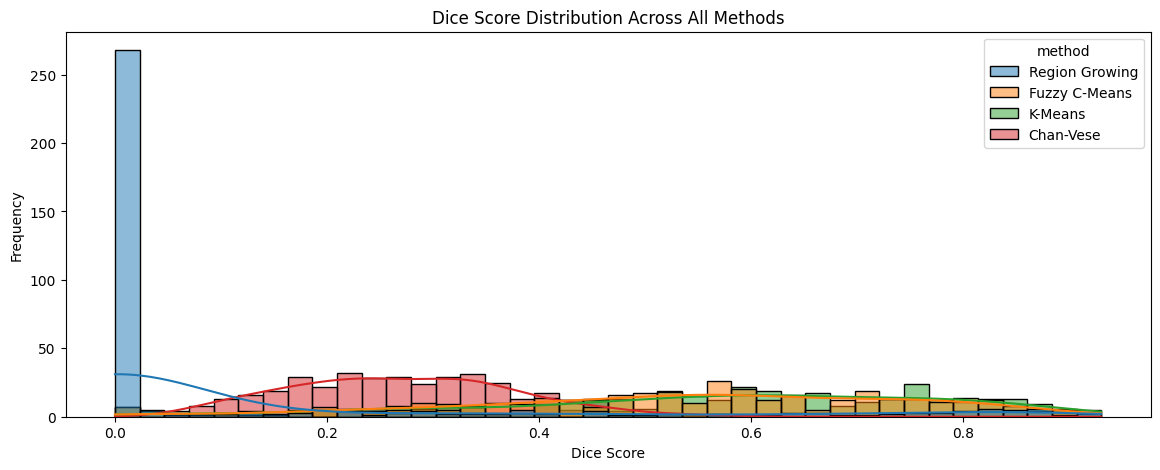

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.figure(figsize=(14,5))
sns.histplot(data=df_all, x='dice', hue='method', kde=True, bins=40)
plt.title("Dice Score Distribution Across All Methods")
plt.xlabel("Dice Score")
plt.ylabel("Frequency")
plt.show()


#### NSD score histogram per method

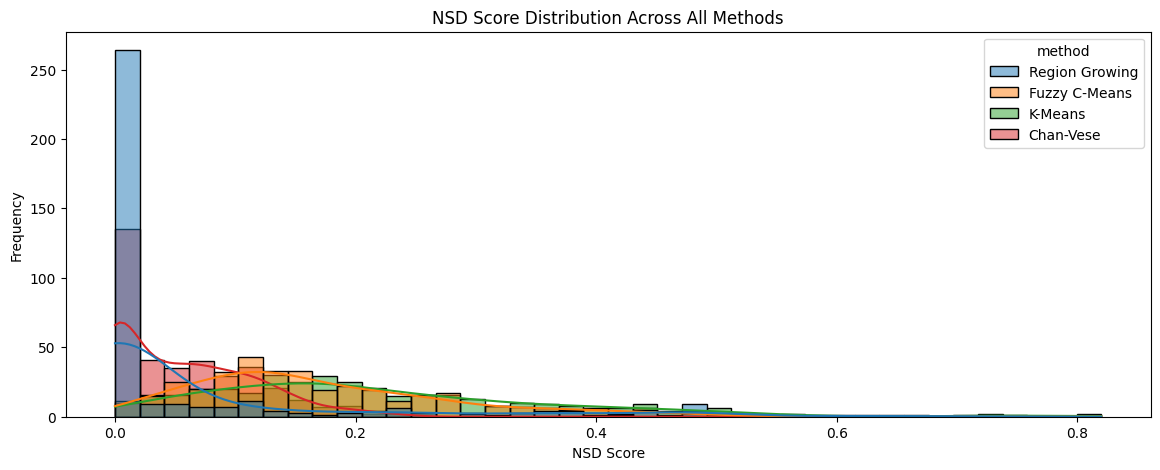

In [70]:
plt.figure(figsize=(14,5))
sns.histplot(data=df_all, x='nsd', hue='method', kde=True, bins=40)
plt.title("NSD Score Distribution Across All Methods")
plt.xlabel("NSD Score")
plt.ylabel("Frequency")
plt.show()

## Boxplots

#### Dice boxplot

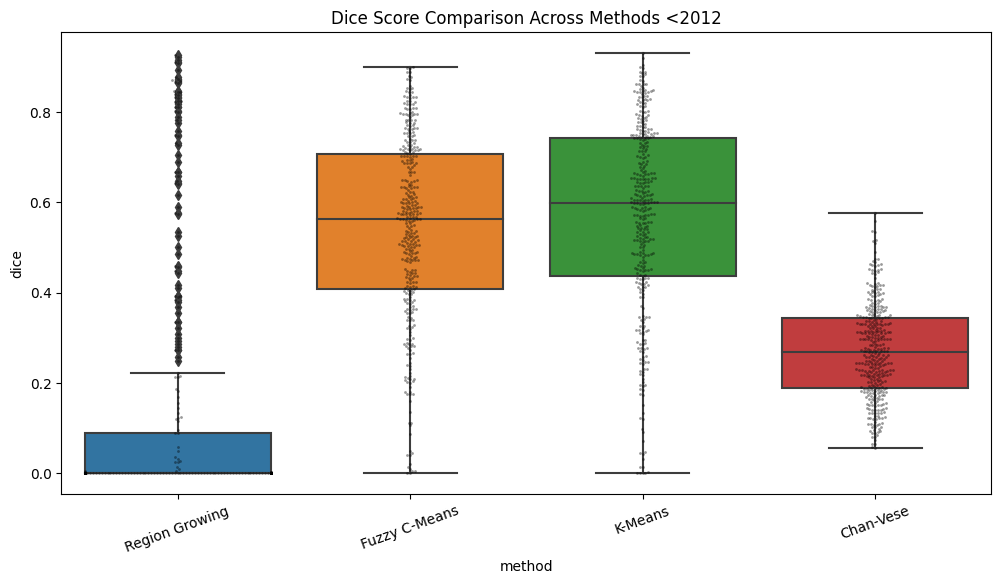

In [73]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_all, x='method', y='dice')
sns.swarmplot(data=df_all, x='method', y='dice', color='black', size=2, alpha=0.4)
plt.title("Dice Score Comparison Across Methods <2012")
plt.xticks(rotation=20)
plt.show()

#### NSD boxplot

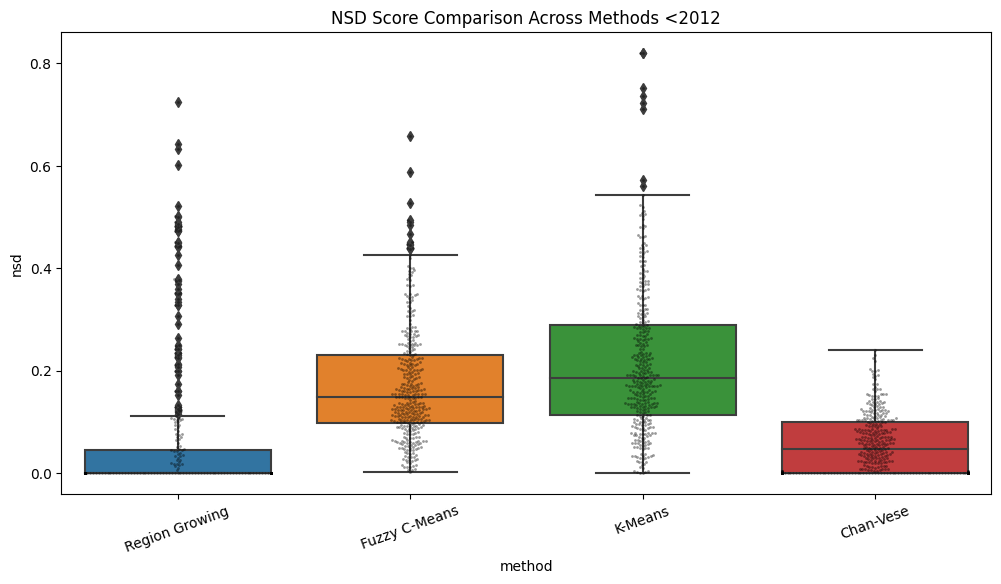

In [74]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_all, x='method', y='nsd')
sns.swarmplot(data=df_all, x='method', y='nsd', color='black', size=2, alpha=0.4)
plt.title("NSD Score Comparison Across Methods <2012")
plt.xticks(rotation=20)
plt.show()